# Course project: Wave problem PINN

We are interested in exploring the wave problem given by:


\begin{equation}
    \begin{cases}
        u_{tt}(x, t)=c^2(x)u_{xx}(x, t) & x\in [0, 1],t\in (0,T] \\
        u(x,0)=u_0(x) & x\in [0, 1]\\
        u_t(x,0)=0 & x\in [0, 1]\\
        u(x,t)=0 & x\in \Omega_1, t\in [0,T]\\
        \frac{\partial u}{\partial x}(x,t)=0 & x\in \Omega_2 t\in [0,T] \qquad \Omega_1\cup\Omega_2=\{l_1, l_2\}, \Omega_1\cap\Omega_2=\{\} \\
    \end{cases}
\end{equation}

where $u(\overrightarrow{x}, t)$ is the wave amplitude or acoustic pressure. For given the initial pressure ($u_0$) and boundary conditions (for types Dirichlet and Neumann with value 0 for perfectly reflecting boundaries) the wave problem is well-posed (small perturbations of the initial conditions result in small perturbations in the solution).
And the initial condition we are going to use is an impulse at $x=0.5$ given by:

$
u_0(x) =
        \begin{cases}
            0 & \text{if } \; \phantom{0.5}0 \leq x < 0.45, \\
            20\,(x-0.45) & \text{if } \; 0.45 \leq x < 0.5, \\
            20\,(0.55-x) & \text{if } \; \phantom{5}0.5 \leq x < 0.55, \\
            0 & \text{if } \; 0.55 \leq x \leq 1 .
        \end{cases}
$

Let us set the parameters of the problem:

In [188]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
import tensorflow as tf

In [189]:
x_lower, x_upper = 0, 1
t_0, n_t = 0, 200
c = 1
dx = 0.01
dt = 0.1 * dx / c
x_points = np.linspace(x_lower, x_upper, int((x_upper - x_lower) / dx) + 1)
t_points = np.linspace(0, n_t * dt, n_t + 1)

## Task 1

For solving the problem analytically, we will use D'Alembert's formula given by:

$
u(x, t) = \frac{F(x - ct) + F(x + ct)}{2} + \frac{1}{2c}\int_{x-ct}^{x+ct}G(s)ds
$

Where $F$ is the odd periodic extension of the initial condition $u_0(x)$ and $G$ is the odd periodic extension of the initial velocity which is 0 in this case. The solution is then reduced to:

$
u(x, t) = \frac{F(x - t) + F(x + t)}{2}
$

We now use Python to show the solution:

In [190]:
def f(x):
    if x >= 0 and x < 0.45:
        return 0
    if x >= 0.45 and x < 0.5:
        return 20 * (x - 0.45)
    if x >= 0.5 and x < 0.55:
        return 20 * (0.55 - x)
    if x >= 0.55 and x <= 1:
        return 0


def f_periodic_extension(x):
    if (x // 1) % 2 == 1:
        return -f(x % 1) # odd
    else:
        return f(x % 1) # even


def u_dalembert(x, t):
    return (f_periodic_extension(x - t) + f_periodic_extension(x + t)) / 2


u_exact = np.zeros((len(x_points), len(t_points)))
for x_index, x_point in enumerate(x_points):
    for t_index, t_point in enumerate(t_points):
        u_exact[x_index, t_index] = u_dalembert(x_point, t_point)

Plot the outputs:

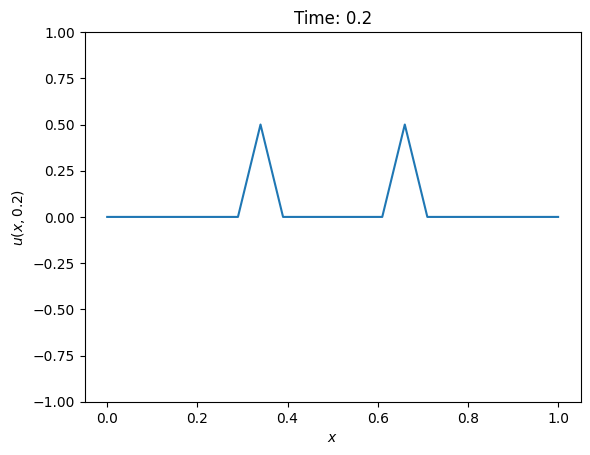

In [191]:
fig, ax = plt.subplots()
line, = ax.plot(x_points, u_exact[:, 0])
ax.set_ylim(-1, 1)
# ax.set_ylim(-1, 1)
def animate_exact(i):
    line.set_data((x_points, u_exact[:, i]))
    time_step = np.round(t_points[i], 1)
    plt.title('Time: ' + str(time_step))
    plt.xlabel('$x$')
    plt.ylabel('$u(x, ' + str(time_step) + ')$')
    return (line,)

anim = animation.FuncAnimation(fig, animate_exact, frames=np.arange(0, n_t, 40), interval=200, blit=True)
HTML(anim.to_jshtml())

## Task 2

We switch to indexed notation (discrete notation) where:

$
\quad u^n_j = u(x_{min} + j \cdot \Delta x, n\cdot \Delta t), \qquad j = 0, ..., N_x, \quad n = 0, ..., N_t$

Time marching scheme given by finite-difference (central-difference in time and space):

$
u_{tt}(x, t) \approx \frac{u^{n + 1} - 2u^{n} + u^{n - 1}}{\Delta t^2}, \qquad u_{xx}(x, t) \approx \frac{u_{j + 1} - 2u_{j} + u_{j - 1}}{\Delta x^2}$

After substituting these to the initial equation we get:

$
u^{n + 1}_j = 2u^{n}_j - u^{n-1}_j + c^2\Delta t^2 \left(\frac{u^n_{j + 1} - 2u^n_{j} + u^n_{j - 1}}{\Delta x ^2} \right)$

We get the initial condition (pressure and velocity) from the exact solution by taking $u(x, 0)$ and $u(x, 1)$ from the previously computed $u_{exact}$.

In [192]:
u_fd = np.zeros((len(x_points), len(t_points)))
u_fd[:, 0] = u_exact[:, 0]
# u_fd[:, 1] = u_exact[:, 1]
u_fd[:, 1] = u_exact[:, 0]  # my numerical way of doing it, if I don't have analytical solution for t=1

for t_step in range(1, n_t):
     u_fd[1:-1, t_step + 1] = 2 * u_fd[1:-1, t_step] - u_fd[1:-1, t_step - 1] + (c ** 2) * (dt ** 2) * (u_fd[2:, t_step] - 2 * u_fd[1:-1, t_step] + u_fd[:-2, t_step]) / (dx ** 2)

And plot:

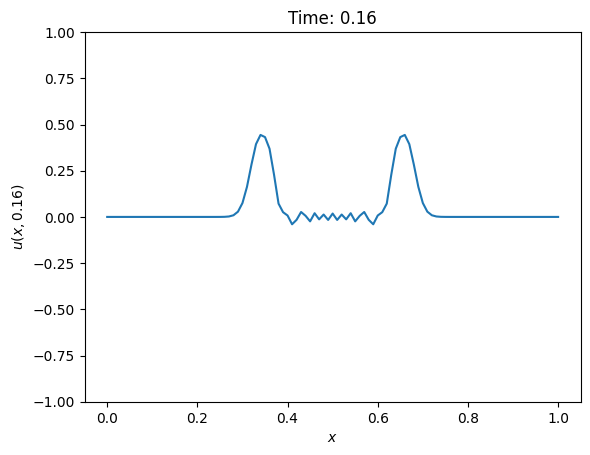

In [193]:
fig, ax = plt.subplots()
line, = ax.plot(x_points, u_fd[:, 0])
ax.set_ylim(-1, 1)
def animate_fd(i):
    line.set_data((x_points, u_fd[:, i]))
    time_step = np.round(t_points[i], 3)
    plt.title('Time: ' + str(time_step))
    plt.xlabel('$x$')
    plt.ylabel('$u(x, ' + str(time_step) + ')$')
    return (line,)

anim = animation.FuncAnimation(fig, animate_fd, frames=np.arange(0, n_t, 40), interval=100, blit=True)
HTML(anim.to_jshtml())

Comparing the numerical solution to the exact solution via $L_2$ norm:

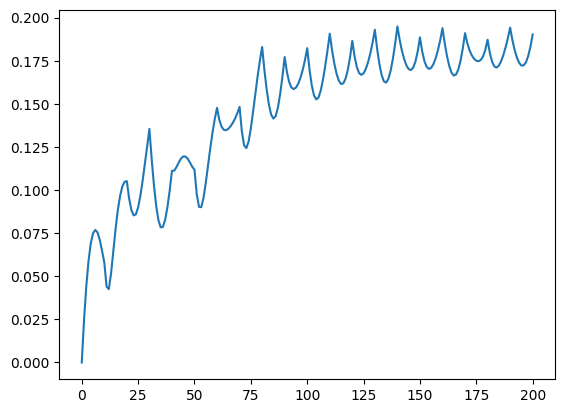

In [194]:
error = np.zeros((len(t_points), 2))
for t_index in range(len(t_points)):
    error[t_index, 0] = np.linalg.norm(u_fd[:, t_index] - u_exact[:, t_index])

plt.plot(error[:, 0])

## Task 3

We will now create a PINN that solves the problem stated in this project. We begin with preparing the data. The data shape will be a set of points. Each point has the $x$ coordinate, $t$ coordinate and the pressure.

In [195]:
all_points_and_pressures = np.zeros((len(x_points) * len(t_points), 3))

outer_index = 0
for x_index, x_point in enumerate(x_points):
    for t_index, t_point in enumerate(t_points):
        all_points_and_pressures[outer_index, 0] = x_point
        all_points_and_pressures[outer_index, 1] = t_point
        all_points_and_pressures[outer_index, 2] = u_exact[x_index, t_index]
        outer_index += 1

# x_grid, t_grid = np.meshgrid(x_points, t_points)
# all_points_pressures = np.vstack(np.stack([x_grid.transpose(), t_grid.transpose(), u_exact], axis=-1))

# init_points = all_points_pressures[np.where(all_points_pressures[:, 0] == 0)]

We then choose from the set of all points, only the one on the initial conditions and the boundary (same as with the numerical method).

In [196]:
data_u_0 = all_points_and_pressures[np.where(all_points_and_pressures[:, 1] == 0)]
data_u_1 = all_points_and_pressures[np.where(all_points_and_pressures[:, 1] == dt)]
data_lower_boundary = all_points_and_pressures[np.where(all_points_and_pressures[:, 0] == x_lower)][2:]  # Starting from the second time step
data_upper_boundary = all_points_and_pressures[np.where(all_points_and_pressures[:, 0] == x_upper)][2:]

u_0_points_train = tf.convert_to_tensor(data_u_0[:, :2], dtype=tf.float32)
u_0_pressures_train =tf.convert_to_tensor(data_u_0[:, 2:], dtype=tf.float32)

u_1_points_train = tf.convert_to_tensor(data_u_1[:, :2], dtype=tf.float32)
u_1_pressures_train =tf.convert_to_tensor(data_u_1[:, 2:], dtype=tf.float32)

lower_boundary_points_train = tf.convert_to_tensor(data_lower_boundary[:, :2], dtype=tf.float32)
lower_boundary_pressures_train =tf.convert_to_tensor(data_lower_boundary[:, 2:], dtype=tf.float32)

upper_boundary_points_train = tf.convert_to_tensor(data_upper_boundary[:, :2], dtype=tf.float32)
upper_boundary_pressures_train =tf.convert_to_tensor(data_upper_boundary[:, 2:], dtype=tf.float32)


# train_data = np.concatenate([data_u_0, data_u_1, data_lower_boundary, data_upper_boundary])

# choice_indexes = np.random.choice(train_data.shape[0], size=500)
# points_train = tf.convert_to_tensor(train_data[:, :2], dtype=tf.float32)
# pressures_train =tf.convert_to_tensor(train_data[:, 2:], dtype=tf.float32)

# points_train = tf.convert_to_tensor(all_points_and_pressures[:, :2], dtype=tf.float32)
# pressures_train =tf.convert_to_tensor(all_points_and_pressures[:, 2:], dtype=tf.float32)

In [197]:
x_vector = tf.convert_to_tensor(all_points_and_pressures[:, 0:1], dtype=tf.float32)
t_vector = tf.convert_to_tensor(all_points_and_pressures[:, 1:2], dtype=tf.float32)
u_vector = tf.convert_to_tensor(all_points_and_pressures[:, 2:], dtype=tf.float32)

Define the network:

In [199]:
# Initalization of Network
def hyper_initial(in_dim, out_dim):
    std = np.sqrt(2.0 / (in_dim + out_dim))
    return tf.Variable(tf.random.truncated_normal(shape=(in_dim, out_dim), stddev = std))

def dnn(inputs, weights, biases):
    hidden = inputs
    num_of_layers = len(weights)
    for index in range(num_of_layers - 1):
        hidden = tf.tanh(tf.add(tf.matmul(hidden, weights[index]), biases[index]))
    outputs = tf.add(tf.matmul(hidden, weights[-1]), biases[-1])
    return outputs

def train_variables(weights, biases):
    return weights + biases

def net_u(x, t, weights, biases):
    u = dnn(tf.concat([x, t], 1), weights, biases)
    return u

def forward(x, t, weights, biases):
    with tf.GradientTape(persistent=True) as tape_2nd_derivative:
        tape_2nd_derivative.watch(x)
        tape_2nd_derivative.watch(t)
        with tf.GradientTape(persistent=True) as tape_1st_derivative:
            tape_1st_derivative.watch(x)
            tape_1st_derivative.watch(t)
            u = net_u(x, t, weights, biases)
        u_x = tape_1st_derivative.gradient(u, x)
        u_t = tape_1st_derivative.gradient(u, t)

        del tape_1st_derivative
    u_xx = tape_2nd_derivative.gradient(u_x, x)
    u_tt = tape_2nd_derivative.gradient(u_t, t)
    del tape_2nd_derivative
    
    return tf.cast(u_tt - (c ** 2) * u_xx, dtype=tf.float32)

@tf.function  # (jit_compile=True)
def train_step(u_0_points, u_0_pressures,
               u_1_points, u_1_pressures,
               lower_boundary_points, lower_boundary_pressures,
               upper_boundary_points, upper_boundary_pressures,
               weights, biases, optimizer):
    with tf.GradientTape() as tape:
        # tape.watch([weights, biases])
        u_0_nn = net_u(u_0_points[:, 0:1], u_0_points[:, 1:2], weights, biases)
        u_1_nn = net_u(u_1_points[:, 0:1], u_1_points[:, 1:2], weights, biases)
        lower_boundary_nn = net_u(lower_boundary_points[:, 0:1], lower_boundary_points[:, 1:2], weights, biases)
        upper_boundary_nn = net_u(upper_boundary_points[:, 0:1], upper_boundary_points[:, 1:2], weights, biases)
        f_nn = forward(x_vector, t_vector, weights, biases)
        
        u_0_loss = tf.reduce_mean(tf.square(u_0_nn - u_0_pressures))
        u_1_loss = tf.reduce_mean(tf.square(u_1_nn - u_1_pressures))
        lower_boundary_loss = tf.reduce_mean(tf.square(lower_boundary_nn - lower_boundary_pressures))
        upper_boundary_loss = tf.reduce_mean(tf.square(upper_boundary_nn - upper_boundary_pressures))
        res_loss = tf.reduce_mean(tf.square(f_nn))

        # total_loss = u_0_loss + 30 * u_1_loss + 10 * lower_boundary_loss + 10 * upper_boundary_loss + res_loss
        total_loss = u_0_loss + 0 * u_1_loss + 10 * lower_boundary_loss + 10 * upper_boundary_loss + res_loss
        grads = tape.gradient(total_loss, train_variables(weights, biases))
    optimizer.apply_gradients(zip(grads, train_variables(weights, biases)))
    return u_0_loss, u_1_loss, lower_boundary_loss, upper_boundary_loss, res_loss

Train the network:

In [200]:
epochs = 100000
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)

layers = [2, 64, 64, 1]
num_of_layers = len(layers)
weights_classical = [hyper_initial(layers[l - 1], layers[l]) for l in range(1, num_of_layers)]
biases_classical = [tf.Variable(tf.zeros([1, layers[l]])) for l in range(1, num_of_layers)]

for epoch in range(epochs):
    u_0_loss, u_1_nn, lower_boundary_nn, upper_boundary_nn, res_loss = train_step(u_0_points_train, u_0_pressures_train, 
                                                                                  u_1_points_train, u_1_pressures_train,
                                                                                  lower_boundary_points_train, lower_boundary_pressures_train, 
                                                                                  upper_boundary_points_train, upper_boundary_pressures_train,
                                                                                  weights_classical, biases_classical, optimizer)
    if epoch % 2000 == 0:
        print('   ---Epoch: ' + str(epoch) + ' of ' + str(epochs) +
              ', ---u_0 loss: ' + str(float(u_0_loss)) +
              ', ---u_1 loss: ' + str(float(u_1_nn)) +
              ', ---lower_boundary loss: ' + str(float(lower_boundary_nn)) +
              ', ---upper_boundary loss: ' + str(float(upper_boundary_nn)) +
              ', ---res loss: ' + str(float(res_loss)))

   ---Epoch: 0 of 100000, ---u_0 loss: 0.040606725960969925, ---u_1 loss: 0.04021497815847397, ---lower_boundary loss: 3.4392153338558273e-06, ---upper_boundary loss: 0.0072372714057564735, ---res loss: 1.1011416972905863e-05
   ---Epoch: 2000 of 100000, ---u_0 loss: 0.03150442987680435, ---u_1 loss: 0.031116338446736336, ---lower_boundary loss: 2.4325311187567422e-06, ---upper_boundary loss: 4.2827487050089985e-05, ---res loss: 1.8670258214115165e-05
   ---Epoch: 4000 of 100000, ---u_0 loss: 0.02882659249007702, ---u_1 loss: 0.02844056487083435, ---lower_boundary loss: 1.7648914081291878e-06, ---upper_boundary loss: 1.3974108696857002e-06, ---res loss: 2.4367333026020788e-05
   ---Epoch: 6000 of 100000, ---u_0 loss: 0.02877088636159897, ---u_1 loss: 0.028385568410158157, ---lower_boundary loss: 1.8652602875590674e-06, ---upper_boundary loss: 2.8698379992420087e-06, ---res loss: 1.1662267752399202e-05
   ---Epoch: 8000 of 100000, ---u_0 loss: 0.028682423755526543, ---u_1 loss: 0.028294

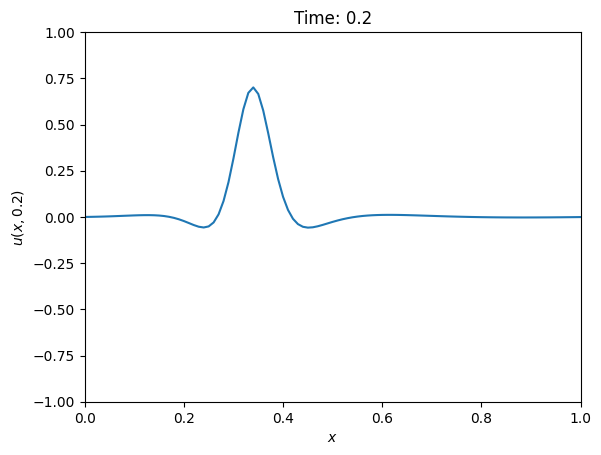

In [201]:
u_pred = net_u(x_vector.numpy(), t_vector.numpy(), weights_classical, biases_classical)

fig, ax = plt.subplots()
line, = ax.plot(x_points, u_pred.numpy()[np.where(all_points_and_pressures[:, 1] == t_points[0])])
ax.set_xlim(x_lower, x_upper)  
ax.set_ylim(-1, 1)
def animate_fd(i):
    line.set_data((x_points, u_pred.numpy()[np.where(all_points_and_pressures[:, 1] == t_points[i])]))
    time_step = np.round(t_points[i], 1)
    plt.title('Time: ' + str(time_step))
    plt.xlabel('$x$')
    plt.ylabel('$u(x, ' + str(time_step) + ')$')
    return (line,)

anim = animation.FuncAnimation(fig, animate_fd, frames=np.arange(0, n_t, 40), interval=100, blit=True)
HTML(anim.to_jshtml())

We now add the results to the energy norm comparison.

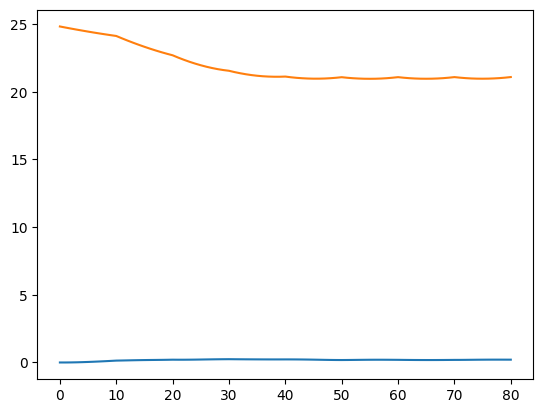

In [55]:
for t_index, t_point in enumerate(t_points):
    u_pred_step = u_pred.numpy()[np.where(all_points_and_pressures[:, 1] == t_point)]
    error[t_index, 1] = np.linalg.norm(u_pred_step - u_exact[:, t_index])

plt.plot(error)

In [202]:
error.shape


(201, 2)

In [203]:
error.shape

(201, 2)

## Task 4

We will use the 19 evenly spread sensors. First, we sample this data from the set of points we produced earlier.

In [173]:
sensors_data = np.concatenate([all_points_and_pressures[np.where(all_points_and_pressures[:, 0] == x_coordinate)] for x_coordinate in x_points[::5]])
sensors_points = tf.convert_to_tensor(sensors_data[:, :2], dtype=tf.float32)
sensors_pressures = tf.convert_to_tensor(sensors_data[:, 2:], dtype=tf.float32)

We adjust the training step since now we do not have the boundary points.

In [174]:
@tf.function  # (jit_compile=True)
def train_step(points, pressures, weights, biases, optimizer):
    with tf.GradientTape() as tape:
        u_nn = net_u(points[:, 0:1], points[:, 1:2], weights, biases)
        f_nn = forward(x_vector, t_vector, weights, biases)
        
        u_loss = tf.reduce_mean(tf.square(u_nn - pressures))
        res_loss = tf.reduce_mean(tf.square(f_nn))

        total_loss = 30 * u_loss + res_loss
        grads = tape.gradient(total_loss, train_variables(weights, biases))
    optimizer.apply_gradients(zip(grads, train_variables(weights, biases)))
    return u_loss, res_loss

We now train the same network for the sensors data.

In [ ]:
weights_sensors = [hyper_initial(layers[l - 1], layers[l]) for l in range(1, num_of_layers)]
biases_sensors = [tf.Variable(tf.zeros([1, layers[l]])) for l in range(1, num_of_layers)]
optimizer_sensors = tf.keras.optimizers.Adam(learning_rate=0.0005)

for epoch in range(epochs):
    nn_loss, res_loss = train_step(sensors_points, sensors_pressures, weights_sensors, biases_sensors, optimizer_sensors)
    if epoch % 5000 == 0:
        print('   ---Epoch: ' + str(epoch) + ' of ' + str(epochs) + ', ---nn loss: ' + str(float(nn_loss))  + ', ---res loss: ' + str(float(res_loss)))

   ---Epoch: 0 of 100000, ---nn loss: 0.01709970086812973, ---res loss: 0.0011627249186858535
   ---Epoch: 5000 of 100000, ---nn loss: 0.009845461696386337, ---res loss: 0.0011401802767068148
   ---Epoch: 10000 of 100000, ---nn loss: 0.009173430502414703, ---res loss: 0.0015470163198187947
   ---Epoch: 15000 of 100000, ---nn loss: 0.008733125403523445, ---res loss: 0.0021485162433236837
   ---Epoch: 20000 of 100000, ---nn loss: 0.008285965770483017, ---res loss: 0.002576311817392707
   ---Epoch: 25000 of 100000, ---nn loss: 0.007632765453308821, ---res loss: 0.0036891757044941187
   ---Epoch: 30000 of 100000, ---nn loss: 0.007248133886605501, ---res loss: 0.0019387758802622557
   ---Epoch: 35000 of 100000, ---nn loss: 0.006699291989207268, ---res loss: 0.002541301306337118
   ---Epoch: 40000 of 100000, ---nn loss: 0.005689184181392193, ---res loss: 0.0023500225506722927
   ---Epoch: 45000 of 100000, ---nn loss: 0.004396885633468628, ---res loss: 0.005576004274189472
   ---Epoch: 50000 

We now check the recovered initial condition to see if we achieved clear indication of the location of the initial impulse.

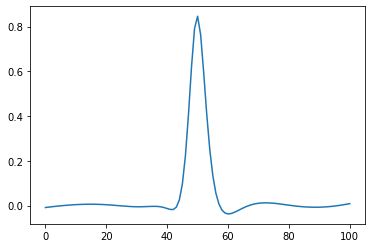

In [ ]:
u_pred_sensors = net_u(x_vector.numpy(), t_vector.numpy(), weights_sensors, biases_sensors)
plt.plot(u_pred_sensors.numpy()[np.where(all_points_and_pressures[:, 1] == 0)])

## Task 5

We now randomly choose sensors with a budget (limited number of sensors).

In [ ]:
sensors_budget = 3
budget_sensors_locations = np.random.choice(x_points[1:-1], sensors_budget)  # Making sure we do not choose a sensors on the boundary
budget_sensors_data = np.concatenate([all_points_and_pressures[np.where(all_points_and_pressures[:, 0] == x_coordinate)] for x_coordinate in budget_sensors_locations])
budget_sensors_points = tf.convert_to_tensor(budget_sensors_data[:, :2], dtype=tf.float32)
budget_sensors_pressures = tf.convert_to_tensor(budget_sensors_data[:, 2:], dtype=tf.float32)

Training the network.

In [ ]:
weights_budget_sensors = [hyper_initial(layers[l - 1], layers[l]) for l in range(1, num_of_layers)]
biases_budget_sensors = [tf.Variable(tf.zeros([1, layers[l]])) for l in range(1, num_of_layers)]

for epoch in range(epochs):
    nn_loss, res_loss = train_step(budget_sensors_points, budget_sensors_pressures, weights_budget_sensors, biases_budget_sensors, optimizer)
    if epoch % 250 == 0:
        print('   ---Epoch: ' + str(epoch) + ' of ' + str(epochs) + ', ---nn loss: ' + str(float(nn_loss))  + ', ---res loss: ' + str(float(res_loss)))

   ---Epoch: 0 of 100000, ---nn loss: 0.021046949550509453, ---res loss: 3.841294892481528e-05
   ---Epoch: 250 of 100000, ---nn loss: 0.011745885945856571, ---res loss: 6.316277722362429e-05
   ---Epoch: 500 of 100000, ---nn loss: 0.011744103394448757, ---res loss: 6.137738091638312e-05
   ---Epoch: 750 of 100000, ---nn loss: 0.01174226775765419, ---res loss: 5.665792923537083e-05
   ---Epoch: 1000 of 100000, ---nn loss: 0.011739887297153473, ---res loss: 5.204925037105568e-05
   ---Epoch: 1250 of 100000, ---nn loss: 0.011736219748854637, ---res loss: 4.89789126731921e-05
   ---Epoch: 1500 of 100000, ---nn loss: 0.011729043908417225, ---res loss: 4.772140891873278e-05
   ---Epoch: 1750 of 100000, ---nn loss: 0.01170858833938837, ---res loss: 4.757587521453388e-05
   ---Epoch: 2000 of 100000, ---nn loss: 0.011642410419881344, ---res loss: 4.6514829591615126e-05
   ---Epoch: 2250 of 100000, ---nn loss: 0.011540128849446774, ---res loss: 7.882934005465358e-05
   ---Epoch: 2500 of 100000,

Check the source refocusing.

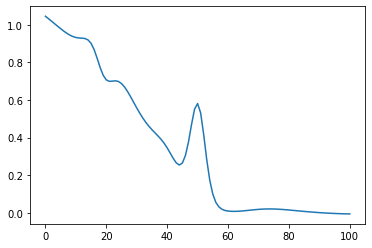

In [ ]:
u_pred_budget_sensors = net_u(x_vector.numpy(), t_vector.numpy(), weights_budget_sensors, biases_budget_sensors)
plt.plot(u_pred_budget_sensors.numpy()[np.where(all_points_and_pressures[:, 1] == 0)])